# Training Run Analysis

Analyze a model training run from `logs/<run_name>/` and `checkpoints/<run_name>_best.pt`.

This notebook checks:
- training and validation curves
- final validation/test/OOD metrics
- overfitting signals
- OOD reliability gap
- optional prediction/error visualizations from the best checkpoint

In [2]:
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

RUN_NAME = "cnn_local_baseline_50ep"
LOG_DIR = ROOT / "logs" / RUN_NAME
CHECKPOINT_PATH = ROOT / "checkpoints" / f"{RUN_NAME}_best.pt"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

print(f"Repo root: {ROOT}")
print(f"Run logs:  {LOG_DIR}")
print(f"Best ckpt: {CHECKPOINT_PATH}")

Repo root: /Users/vicki/digital-twin-heat-surrogate
Run logs:  /Users/vicki/digital-twin-heat-surrogate/logs/cnn_local_baseline_50ep
Best ckpt: /Users/vicki/digital-twin-heat-surrogate/checkpoints/cnn_local_baseline_50ep_best.pt


## Load Run Artifacts

In [3]:
def read_json(path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def read_history(path):
    with path.open("r", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    history = {}
    for key in rows[0].keys():
        values = [row[key] for row in rows]
        if key == "epoch":
            history[key] = np.array(values, dtype=int)
        else:
            history[key] = np.array(values, dtype=float)
    return history

config = read_json(LOG_DIR / "config.json")
metrics = read_json(LOG_DIR / "metrics.json")
history = read_history(LOG_DIR / "history.csv")

print("Config summary")
for key in ["model", "run_name", "device", "epochs", "batch_size", "lr", "hidden_channels", "depth", "parameter_count"]:
    print(f"  {key:>16s}: {config[key]}")

print("\nBest epoch:", metrics["best_epoch"])
print("Best val loss:", metrics["best_val_loss"])

Config summary
             model: cnn
          run_name: cnn_local_baseline_50ep
            device: mps
            epochs: 50
        batch_size: 32
                lr: 0.001
   hidden_channels: 64
             depth: 5
   parameter_count: 113153

Best epoch: 44
Best val loss: 0.00179690676741302


## Training Curves

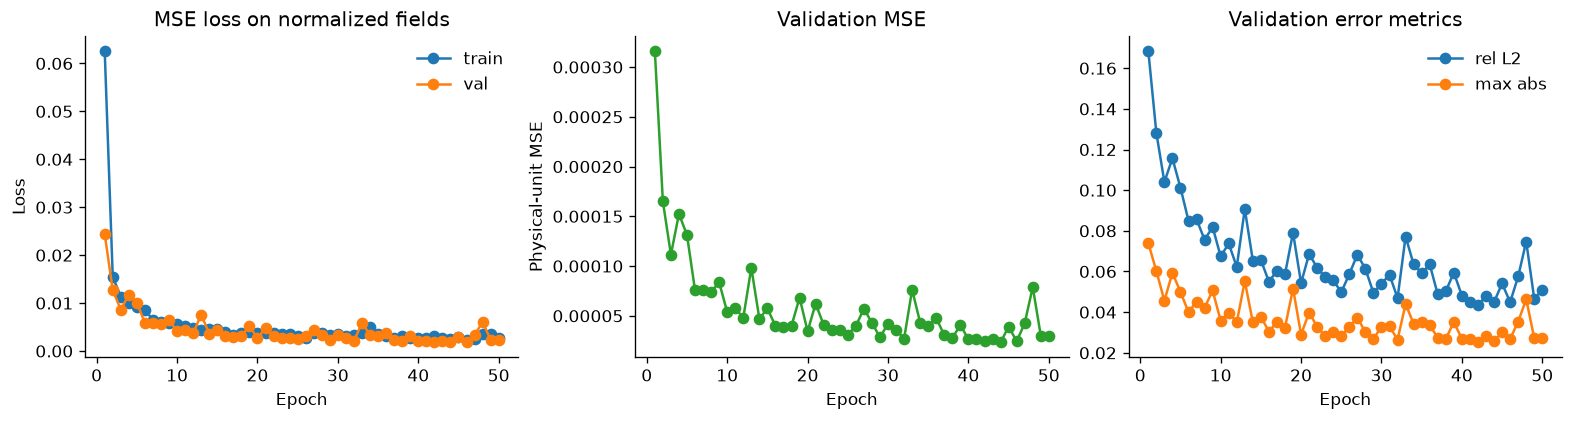

Saved /Users/vicki/digital-twin-heat-surrogate/figures/cnn_local_baseline_50ep_training_curves.png


In [4]:
epochs = history["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)

axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
axes[0].set_title("MSE loss on normalized fields")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=False)

axes[1].plot(epochs, history["val_mse"], marker="o", color="tab:green")
axes[1].set_title("Validation MSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Physical-unit MSE")

axes[2].plot(epochs, history["val_rel_l2"], marker="o", label="rel L2")
axes[2].plot(epochs, history["val_max_abs"], marker="o", label="max abs")
axes[2].set_title("Validation error metrics")
axes[2].set_xlabel("Epoch")
axes[2].legend(frameon=False)

out_path = FIGURE_DIR / f"{RUN_NAME}_training_curves.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Final Metrics

In [5]:
split_names = ["val", "test", "ood_corner", "ood_multi"]
metric_names = ["mse", "rel_l2", "max_abs"]

for split in split_names:
    print(f"\n{split}")
    for metric in metric_names:
        print(f"  {metric:>8s}: {metrics[split][metric]:.6g}")

test_rel = metrics["test"]["rel_l2"]
corner_rel = metrics["ood_corner"]["rel_l2"]
multi_rel = metrics["ood_multi"]["rel_l2"]
print("\nOOD / test relative-L2 ratios")
print(f"  corner: {corner_rel / test_rel:.2f}x")
print(f"  multi:  {multi_rel / test_rel:.2f}x")


val
       mse: 2.32756e-05
    rel_l2: 0.0449469
   max_abs: 0.0259434

test
       mse: 2.2209e-05
    rel_l2: 0.0443524
   max_abs: 0.0255679

ood_corner
       mse: 2.76209e-05
    rel_l2: 0.0565652
   max_abs: 0.0340694

ood_multi
       mse: 4.08127e-05
    rel_l2: 0.0489485
   max_abs: 0.0355923

OOD / test relative-L2 ratios
  corner: 1.28x
  multi:  1.10x


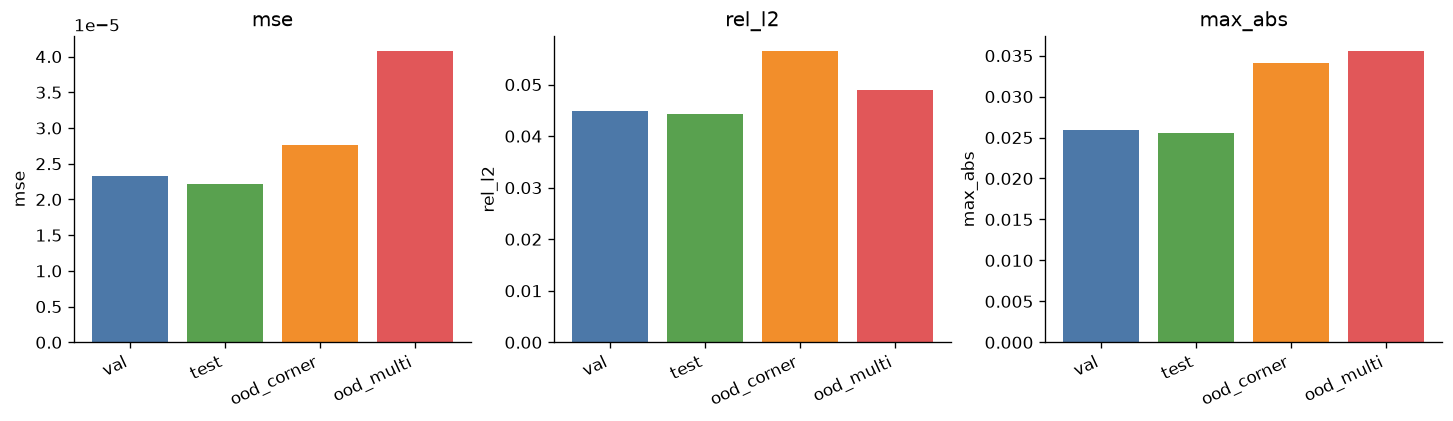

Saved /Users/vicki/digital-twin-heat-surrogate/figures/cnn_local_baseline_50ep_final_metrics.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
x = np.arange(len(split_names))

for ax, metric in zip(axes, metric_names):
    values = [metrics[split][metric] for split in split_names]
    ax.bar(x, values, color=["#4C78A8", "#59A14F", "#F28E2B", "#E15759"])
    ax.set_xticks(x)
    ax.set_xticklabels(split_names, rotation=25, ha="right")
    ax.set_title(metric)
    ax.set_ylabel(metric)

out_path = FIGURE_DIR / f"{RUN_NAME}_final_metrics.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Quick Training Verdict

In [7]:
best_epoch = metrics["best_epoch"]
last_epoch = int(history["epoch"][-1])
train_last = history["train_loss"][-1]
val_last = history["val_loss"][-1]
val_best = np.min(history["val_loss"])
gap = val_last - train_last

print(f"Best epoch: {best_epoch} / {last_epoch}")
print(f"Final train loss: {train_last:.6f}")
print(f"Final val loss:   {val_last:.6f}")
print(f"Best val loss:    {val_best:.6f}")
print(f"Val-train gap:    {gap:.6f}")

if best_epoch == last_epoch:
    print("Verdict: validation was still improving at the end; a longer run is probably useful.")
elif gap > 0.5 * train_last:
    print("Verdict: possible overfitting; watch the validation curve on longer runs.")
else:
    print("Verdict: training looks stable for this run.")

Best epoch: 44 / 50
Final train loss: 0.002657
Final val loss:   0.002272
Best val loss:    0.001797
Val-train gap:    -0.000385
Verdict: training looks stable for this run.


## Prediction Visualization from Best Checkpoint

This section requires PyTorch. If PyTorch is not available in the notebook kernel, the previous metric plots are still useful.

In [8]:
try:
    import torch
    from dataset import HeatDataset, NormalizationStats, load_normalization_stats
    from models import HeatCNN
    TORCH_AVAILABLE = True
except Exception as exc:
    TORCH_AVAILABLE = False
    print(f"Skipping checkpoint visualization because PyTorch import failed: {exc}")

TORCH_AVAILABLE

True

In [9]:
if TORCH_AVAILABLE:
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    stats = load_normalization_stats(ROOT / "data")

    model = HeatCNN(
        hidden_channels=config["hidden_channels"],
        depth=config["depth"],
        residual_initial=not config["no_residual_initial"],
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} on {device}")

Loaded checkpoint from epoch 44 on mps


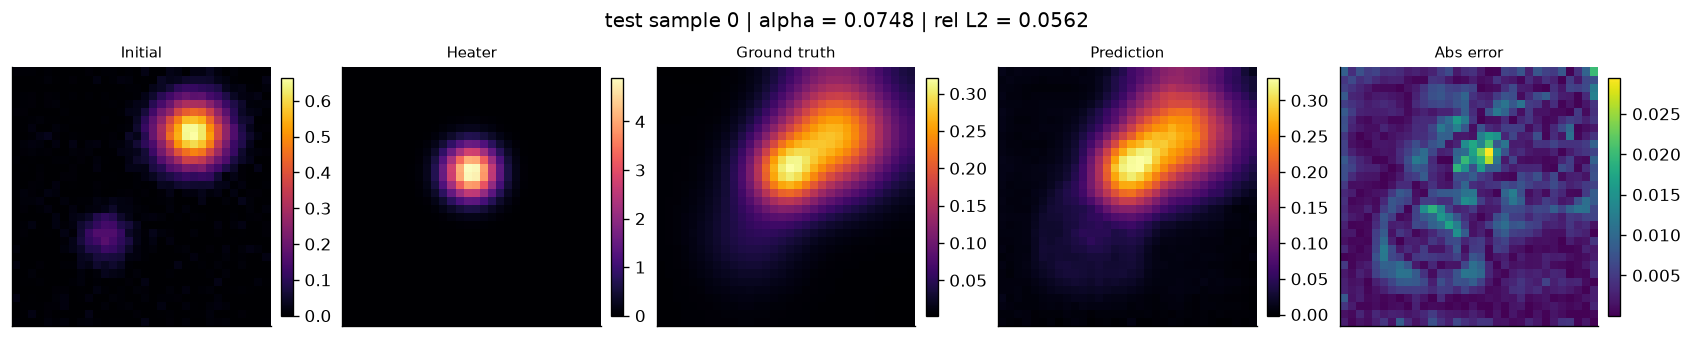

Saved /Users/vicki/digital-twin-heat-surrogate/figures/cnn_local_baseline_50ep_test_prediction.png


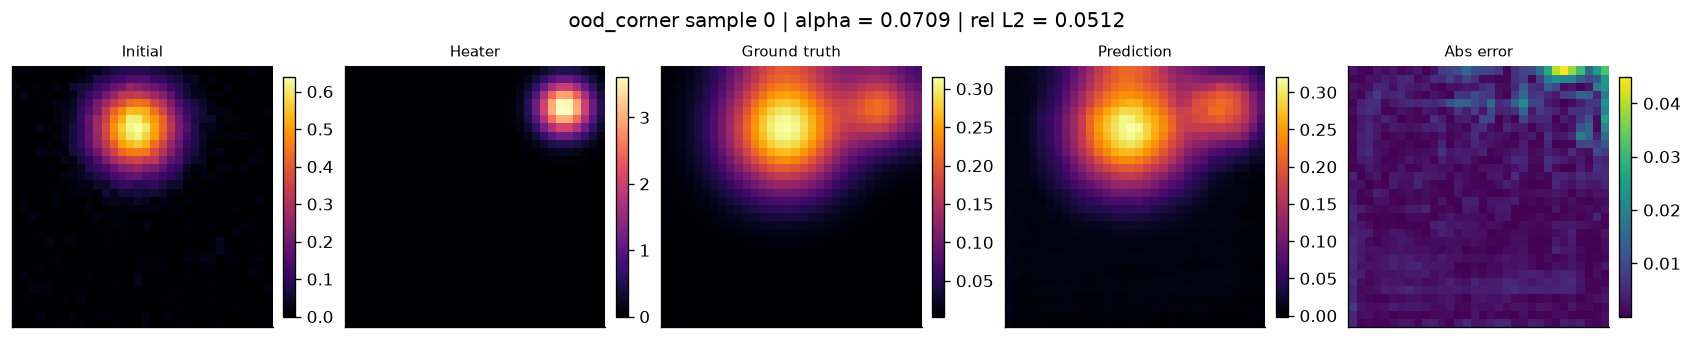

Saved /Users/vicki/digital-twin-heat-surrogate/figures/cnn_local_baseline_50ep_ood_corner_prediction.png


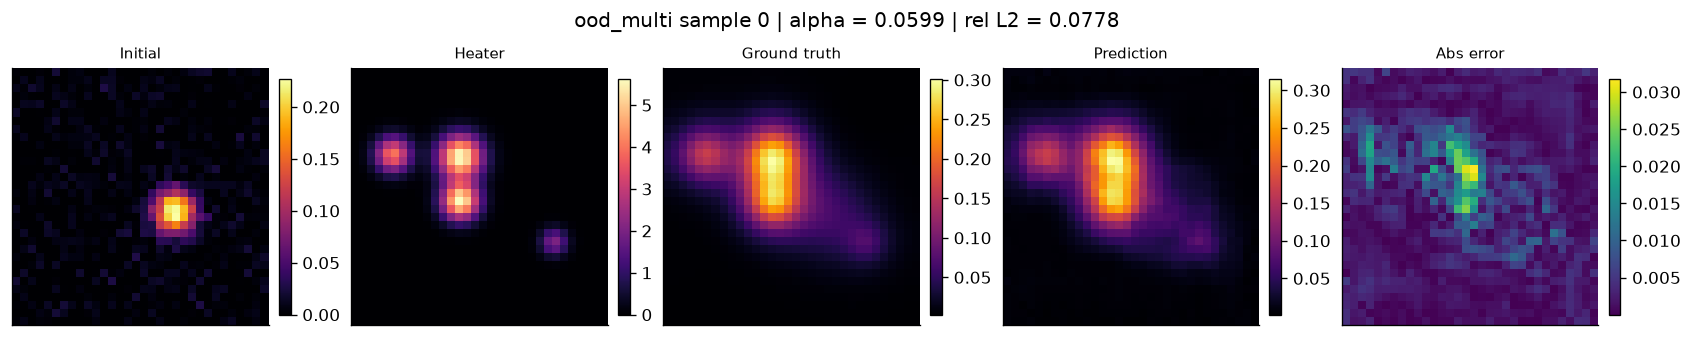

Saved /Users/vicki/digital-twin-heat-surrogate/figures/cnn_local_baseline_50ep_ood_multi_prediction.png


In [10]:
def denormalize_y_np(y_norm, stats):
    return y_norm * float(stats.y_std.flatten()[0]) + float(stats.y_mean.flatten()[0])

def plot_prediction(split="test", idx=0):
    ds = HeatDataset(ROOT / "data" / f"{split}.npz", stats=stats, normalize=True)
    sample = ds[idx]
    x = sample["x"].unsqueeze(0).to(device)
    y = sample["y"].unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x)

    x_phys = ds.x[idx].numpy()
    y_phys = denormalize_y_np(y.squeeze().cpu().numpy(), stats)
    pred_phys = denormalize_y_np(pred.squeeze().cpu().numpy(), stats)
    err = np.abs(pred_phys - y_phys)

    fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), constrained_layout=True)
    fields = [x_phys[0], x_phys[1], y_phys, pred_phys, err]
    titles = ["Initial", "Heater", "Ground truth", "Prediction", "Abs error"]
    cmaps = ["inferno", "magma", "inferno", "inferno", "viridis"]
    for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
        im = ax.imshow(field, origin="lower", cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    alpha = float(ds.alpha[idx])
    rel_l2 = np.linalg.norm((pred_phys - y_phys).ravel()) / (np.linalg.norm(y_phys.ravel()) + 1e-8)
    fig.suptitle(f"{split} sample {idx} | alpha = {alpha:.4f} | rel L2 = {rel_l2:.4f}", y=1.05)
    return fig

if TORCH_AVAILABLE:
    for split in ["test", "ood_corner", "ood_multi"]:
        fig = plot_prediction(split=split, idx=0)
        out_path = FIGURE_DIR / f"{RUN_NAME}_{split}_prediction.png"
        fig.savefig(out_path, bbox_inches="tight")
        plt.show()
        print(f"Saved {out_path}")

## Notes for README Results

For a polished first result, report the test metrics and the OOD gap. For this smoke test, the main thing to check is that the pipeline runs end to end. A longer baseline run is worth doing if the best epoch is the last epoch.